# Sangamon River Basin - Watershed Maps

This notebook loads hydrological data for the Sangamon River basin and generates several maps to visualize different aspects of the watershed structure relative to selected USGS gauges. Gauge coordinates are fetched dynamically from the USGS Water Services API.

**Maps Generated:**
1. Flowline network and Gauge locations.
2. Hillslopes (NHD catchments) and Gauge locations.
3. Individual USGS catchment areas defined by selected gauges.
4. (Placeholder) Watershed segmentation based on link order.

**Common Elements:** All maps show gauge locations (points with IDs), highlighting the most downstream gauge. Maps 1 and 3 also show the flowline network.


In [24]:
# %pip install geopandas matplotlib cartopy requests # Uncomment if needed

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests # Needed for fetching data from URL
from pathlib import Path
from matplotlib.patches import Patch
from cartopy.crs import PlateCarree
from cartopy.feature import BORDERS, COASTLINE, STATES
import matplotlib.patheffects as pe
import time # To add delays between API calls if needed

# Define the map projection used throughout
plate_carre = PlateCarree()

## 1. Configuration and Helper Functions

 Define file paths, select target gauges, and define helper functions for data loading and coordinate fetching.


In [25]:
# --- Configuration ---
sangamon_gauge_ids = [ # List of target gauge IDs
    # Ensure these are valid 8-digit USGS site numbers
    "05578100",
    "05578000",
    "05579630",
    "05576500",
    "05580950",
    "05577500",
    "05576250",
    "05576000",
    "05580000",
    "05582000",
    "05576193",
    "05583000",
    "05570910",
    "05578250",
    "05576090",
    "05573540",
    "05578500",
    "05579725",
    "05579500",
    "05572000",
]
# Clean the list to ensure all are strings and stripped
sangamon_gauge_ids = [str(gid).strip() for gid in sangamon_gauge_ids]
most_downstream_gauge_id = str('05583000').strip() # Define the outlet gauge ID

# --- File Paths ---
usgs_basins_file = "usgs-basins.geojson"
catchment_nhd_file = "Catchment-05583000.gpkg" # Hillslopes
flowline_nhd_file = "NHDFlowline-05583000.gpkg" # River network

# --- Helper Function for Loading GeoDataFrames ---
def load_gdf(filepath, expected_crs="EPSG:4326"):
    """Loads a geospatial file into a GeoDataFrame and sets CRS."""
    print(f"Loading GeoDataFrame from: {filepath}")
    if not Path(filepath).is_file():
        print(f"  Error: File not found at {filepath}")
        return None
    try:
        gdf = gpd.read_file(filepath)
        if gdf.empty:
             print(f"  Warning: File loaded but contains no features: {filepath}")
             return gdf # Return empty gdf
        if gdf.geometry.isnull().all():
             print(f"  Warning: No valid geometries found in {filepath}")
        # Set CRS if missing or incorrect
        if gdf.crs is None:
            print(f"  Warning: CRS missing, assuming {expected_crs}.")
            gdf.set_crs(epsg=expected_crs.split(':')[-1], inplace=True)
        elif gdf.crs.to_string() != expected_crs:
            print(f"  Converting CRS from {gdf.crs} to {expected_crs}.")
            gdf = gdf.to_crs(epsg=expected_crs.split(':')[-1])
        print(f"  Loaded {len(gdf)} features with CRS {gdf.crs}.")
        return gdf
    except Exception as e:
        print(f"  Error loading {filepath}: {type(e).__name__} - {e}")
        return None

# --- Helper Function to Fetch USGS Gauge Coordinates ---
def get_usgs_coords(usgs_id):
    """Fetches latitude and longitude for a given USGS gauge ID from NWIS."""
    usgs_id_str = str(usgs_id).zfill(8)
    url = f"https://waterservices.usgs.gov/nwis/site/?format=rdb&sites={usgs_id_str}&siteOutput=expanded&siteStatus=all"
    print(f"  Fetching coordinates for {usgs_id_str}...")
    try:
        r = requests.get(url, timeout=20)
        r.raise_for_status()
        lat, lon = None, None
        lines = r.text.splitlines()
        content_lines = [line for line in lines if not line.startswith('#') and line.strip()]
        if len(content_lines) < 3:
             print(f"  Warning: Unexpected RDB format or no data returned for {usgs_id_str}. Found {len(content_lines)} content lines.")
             return None, None
        header_line, data_line = content_lines[0], content_lines[2]
        header, values = header_line.split('\t'), data_line.split('\t')
        lat_col_name, lon_col_name = 'dec_lat_va', 'dec_long_va'
        try:
            lat_idx, lon_idx = header.index(lat_col_name), header.index(lon_col_name)
        except ValueError:
            print(f"  Warning: Could not find '{lat_col_name}' or '{lon_col_name}' columns in RDB header for {usgs_id_str}.")
            return None, None
        if lat_idx < len(values) and lon_idx < len(values):
            lat_str, lon_str = values[lat_idx], values[lon_idx]
            try:
                if lat_str.strip() and lon_str.strip():
                    lat, lon = float(lat_str), float(lon_str)
                    print(f"  Found Lat: {lat}, Lon: {lon}")
                    return lat, lon
                else: print(f"  Warning: Empty lat/lon value found for {usgs_id_str}.")
            except ValueError: print(f"  Warning: Could not parse lat/lon float for {usgs_id_str}. Values: '{lat_str}', '{lon_str}'")
        else: print(f"  Warning: Lat/lon indices ({lat_idx}, {lon_idx}) out of bounds for data line len ({len(values)}) for {usgs_id_str}")
        return None, None
    except requests.exceptions.RequestException as e: print(f"  Error during API request for {usgs_id_str}: {e}")
    except Exception as e: print(f"  Unexpected error processing coords for {usgs_id_str}: {type(e).__name__} - {e}")
    return None, None

## 2. Data Loading and Processing

Load catchment polygons, NHD data, and fetch gauge coordinates using the API function.


In [26]:
# --- Load Geospatial Data (Catchments, NHD) ---
usgs_gdf = load_gdf(usgs_basins_file)
catchment_nhd = load_gdf(catchment_nhd_file)
flowline_nhd = load_gdf(flowline_nhd_file)

# --- Filter USGS Catchments & Add Warning ---
usgs_catchments = gpd.GeoDataFrame() # Initialize empty
missing_catchment_ids = []
if usgs_gdf is not None:
    if 'usgs_id' in usgs_gdf.columns:
        # Ensure usgs_id column is string for reliable comparison
        usgs_gdf['usgs_id'] = usgs_gdf['usgs_id'].astype(str).str.strip()
        usgs_catchments = usgs_gdf[usgs_gdf['usgs_id'].isin(sangamon_gauge_ids)].copy()
        print(f"Filtered to {len(usgs_catchments)} USGS gauge catchments.")
        # --- Added Warning Check ---
        found_catchment_ids = set(usgs_catchments['usgs_id'])
        required_catchment_ids = set(sangamon_gauge_ids)
        missing_catchment_ids = required_catchment_ids - found_catchment_ids
        if missing_catchment_ids:
             print(f"  Warning: The following gauge IDs had no corresponding catchment polygon in {usgs_basins_file}: {missing_catchment_ids}")
        # --- End Warning Check ---
    else:
        print(f"Error: Column 'usgs_id' not found in {usgs_basins_file}.")

# --- Fetch Gauge Point Locations via API ---
gauge_data_list = []
missing_coord_ids = [] # Keep track of IDs where coord fetch failed
print("\nFetching gauge coordinates via USGS API...")
for gauge_id in sangamon_gauge_ids:
    lat, lon = get_usgs_coords(gauge_id)
    if lat is not None and lon is not None:
        gauge_data_list.append({'gauge_id': str(gauge_id).zfill(8), 'lat': lat, 'lon': lon})
    else:
        print(f"  Failed to retrieve coordinates for gauge: {gauge_id}")
        missing_coord_ids.append(str(gauge_id).zfill(8)) # Add to list of failures
    time.sleep(0.1) # Be polite to the API server

# --- Create GeoDataFrame from Fetched Coordinates ---
gauge_points = gpd.GeoDataFrame(columns=['gauge_id', 'geometry'], crs="EPSG:4326") # Initialize empty
if gauge_data_list:
    gauge_loc_df = pd.DataFrame(gauge_data_list)
    try:
        gauge_points = gpd.GeoDataFrame(
            gauge_loc_df,
            geometry=gpd.points_from_xy(gauge_loc_df.lon, gauge_loc_df.lat),
            crs="EPSG:4326"
        )
        # Ensure gauge_id column exists and is string
        gauge_points['gauge_id'] = gauge_points['gauge_id'].astype(str)
        print(f"\nSuccessfully created GeoDataFrame for {len(gauge_points)} gauge points.")
        if missing_coord_ids:
             print(f"  Note: Coordinate fetching failed for {len(missing_coord_ids)} gauge IDs: {missing_coord_ids}")

    except Exception as e:
        print(f"Error creating GeoDataFrame from fetched coordinates: {type(e).__name__} - {e}")

if gauge_points.empty:
     print("!!! Gauge points could not be created - maps will not show gauge points !!!")


# --- Get Overall Watershed Boundary ---
overall_bounds = None
if not usgs_catchments.empty:
    try:
        if 'usgs_id' in usgs_catchments.columns:
            # Ensure ID for matching is string
            most_downstream_gauge_id_str = str(most_downstream_gauge_id).strip()
            downstream_catchment = usgs_catchments[usgs_catchments['usgs_id'] == most_downstream_gauge_id_str]
            if not downstream_catchment.empty:
                 overall_watershed_geom = downstream_catchment.geometry.iloc[0]
                 overall_bounds = overall_watershed_geom.bounds
                 print(f"Overall watershed boundary defined by gauge: {most_downstream_gauge_id_str}")
            else:
                 print(f"Error: Most downstream gauge '{most_downstream_gauge_id_str}' not found in loaded catchments!")
        else:
             print("Error: 'usgs_id' column missing in usgs_catchments GeoDataFrame.")
    except Exception as e: # Catch potential errors during geometry access
        print(f"Error accessing geometry for downstream gauge: {type(e).__name__} - {e}")


if overall_bounds is None and flowline_nhd is not None and not flowline_nhd.empty:
     print("!!! Cannot determine overall watershed boundary from gauge polygon. Using flowline bounds as fallback.")
     overall_bounds = flowline_nhd.total_bounds
elif overall_bounds is None:
     print("!!! Cannot determine overall watershed boundary. Map extent might be incorrect.")
     overall_bounds = (-89.5, 40.0, -88.5, 41.0) # Example fallback extent

Loading GeoDataFrame from: usgs-basins.geojson
  Converting CRS from EPSG:4269 to EPSG:4326.
  Loaded 7590 features with CRS EPSG:4326.
Loading GeoDataFrame from: Catchment-05583000.gpkg
  Converting CRS from EPSG:4269 to EPSG:4326.
  Loaded 4771 features with CRS EPSG:4326.
Loading GeoDataFrame from: NHDFlowline-05583000.gpkg


/home/zli333/virtenvs/Hydro_cuda/lib/python3.11/site-packages/pyogrio/raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiLineString' is converted to 'MultiLineString Z'
  return ogr_read(


  Converting CRS from EPSG:4269 to EPSG:4326.
  Loaded 4655 features with CRS EPSG:4326.
Filtered to 16 USGS gauge catchments.

Fetching gauge coordinates via USGS API...
  Fetching coordinates for 05578100...
  Found Lat: 40.22788889, Lon: -88.66056389
  Fetching coordinates for 05578000...
  Found Lat: 40.0133333, Lon: -89.8383333
  Fetching coordinates for 05579630...
  Found Lat: 40.4583333, Lon: -88.8775
  Fetching coordinates for 05576500...
  Found Lat: 39.84312778, Lon: -89.5474778
  Fetching coordinates for 05580950...
  Found Lat: 40.4711972, Lon: -89.0289611
  Fetching coordinates for 05577500...
  Found Lat: 39.81541667, Lon: -89.6994167
  Fetching coordinates for 05576250...
  Found Lat: 39.77913889, Lon: -89.5925278
  Fetching coordinates for 05576000...
  Found Lat: 39.7422222, Lon: -89.5672778
  Fetching coordinates for 05580000...
  Found Lat: 40.25476389, Lon: -89.1294278
  Fetching coordinates for 05582000...
  Found Lat: 40.13185556, Lon: -89.7357139
  Fetching coor

## 3. Map Plotting Helper Functions

These functions set up the basic map elements and plot gauge points/labels to avoid repetition.


In [27]:
# (Keep create_basin_map and plot_gauges functions as they were in the previous correct version)
def create_basin_map(bounds, title="Sangamon River Basin Map"):
    """Creates a Cartopy map axes centered on the watershed."""
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': plate_carre})
    ax.add_feature(COASTLINE, zorder=1, linewidth=0.5, edgecolor='gray')
    ax.add_feature(BORDERS, zorder=1, linewidth=0.5, edgecolor='gray')
    ax.add_feature(STATES, zorder=1, linewidth=0.5, edgecolor='gray')

    buffer = 0.05
    if bounds and len(bounds) == 4 and all(isinstance(b, (int, float)) for b in bounds):
        extent = [bounds[0] - buffer, bounds[2] + buffer, bounds[1] - buffer, bounds[3] + buffer]
        try:
            ax.set_extent(extent, crs=plate_carre)
        except Exception as e:
            print(f"Warning: Could not set map extent {extent}. Error: {e}")
    else:
        print("Warning: Invalid overall_bounds provided for map extent.")

    gl = ax.gridlines(draw_labels=True, crs=plate_carre, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlines = False
    gl.ylines = False
    ax.set_title(title)
    return fig, ax

def plot_gauges(ax, gauge_points_gdf, downstream_id):
    """Helper to plot gauge points and labels, highlighting the downstream gauge."""
    # Ensure downstream_id is padded string for comparison
    downstream_id_str = str(downstream_id).zfill(8)

    if not isinstance(gauge_points_gdf, gpd.GeoDataFrame) or gauge_points_gdf.empty:
        print("Skipping gauge plotting - no valid gauge points data loaded.")
        return

    try:
        # Ensure gauge_id column is string type before comparison/plotting
        gauge_points_gdf['gauge_id'] = gauge_points_gdf['gauge_id'].astype(str)

        gauge_points_gdf.plot(ax=ax, marker='o', color='red', markersize=40, edgecolor='black', zorder=5)

        downstream_gauge = gauge_points_gdf[gauge_points_gdf['gauge_id'] == downstream_id_str]
        if not downstream_gauge.empty:
            downstream_gauge.plot(ax=ax, marker='*', color='yellow', markersize=150,
                                  edgecolor='black', zorder=6, label=f"Downstream: {downstream_id_str}")
            ax.legend(fontsize='medium', loc='best')

        path_effects = [pe.withStroke(linewidth=3, foreground="white")]
        plotted_count = 0
        for idx, row in gauge_points_gdf.iterrows():
            if row.geometry is None or row.geometry.is_empty: continue
            # Use the gauge_id directly from the GeoDataFrame row
            label_id = row.gauge_id
            ax.text(row.geometry.x + 0.006, row.geometry.y + 0.006, label_id,
                    transform=plate_carre, fontsize=9, zorder=7,
                    fontweight='bold', path_effects=path_effects)
            plotted_count += 1
        print(f"Attempted to plot {plotted_count} gauge points and labels.")
    except Exception as e:
        print(f"Error during gauge plotting: {type(e).__name__} - {e}")

## 4. Map 1: Flowline Network and Gauge Locations

This map shows the river network and the locations of the USGS gauges.



--- Generating Map 1: Flowline Network and Gauges ---
Plotted flowlines.
Attempted to plot 20 gauge points and labels.


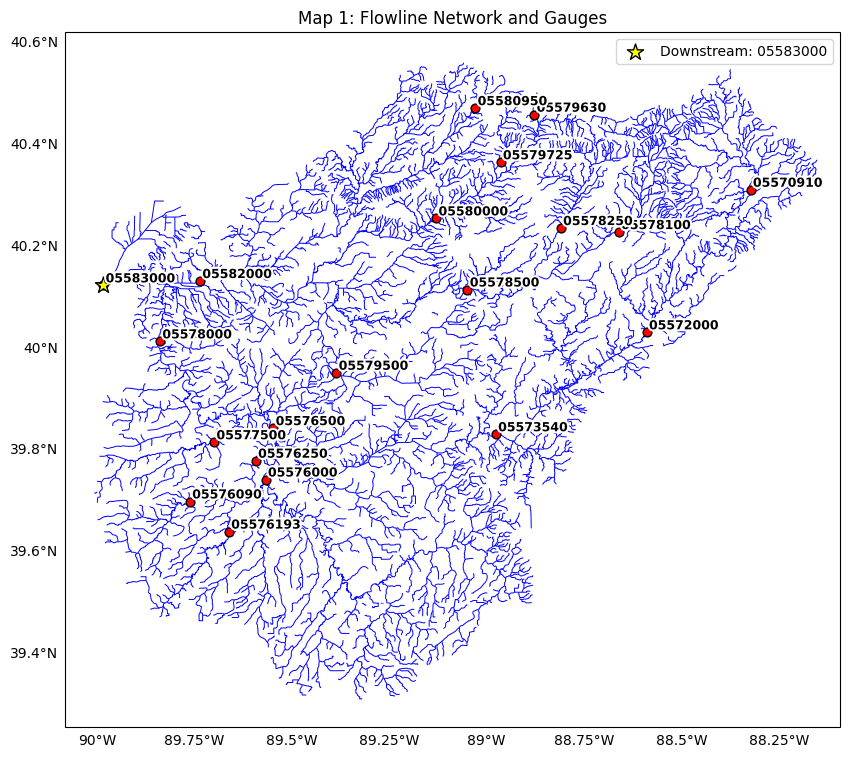

In [28]:
print("\n--- Generating Map 1: Flowline Network and Gauges ---")
# Check if necessary data is available
if overall_bounds and (flowline_nhd is not None and not flowline_nhd.empty):
    fig1, ax1 = create_basin_map(overall_bounds, title="Map 1: Flowline Network and Gauges")

    # Plot NHD flowlines
    flowline_nhd.plot(ax=ax1, lw=0.7, color="blue", zorder=3) # Standard blue flowlines
    print("Plotted flowlines.")

    # Plot gauge points and labels
    plot_gauges(ax1, gauge_points, most_downstream_gauge_id)

    plt.show()
else:
    print("Skipping Map 1 due to missing boundary or NHD flowline data.")

## 5. Map 2: Hillslopes and Gauge Locations

This map shows the detailed NHD catchment boundaries (hillslopes) covering the watershed, along with gauge locations.



--- Generating Map 2: Hillslopes and Gauges ---
Plotted hillslopes.
Attempted to plot 20 gauge points and labels.


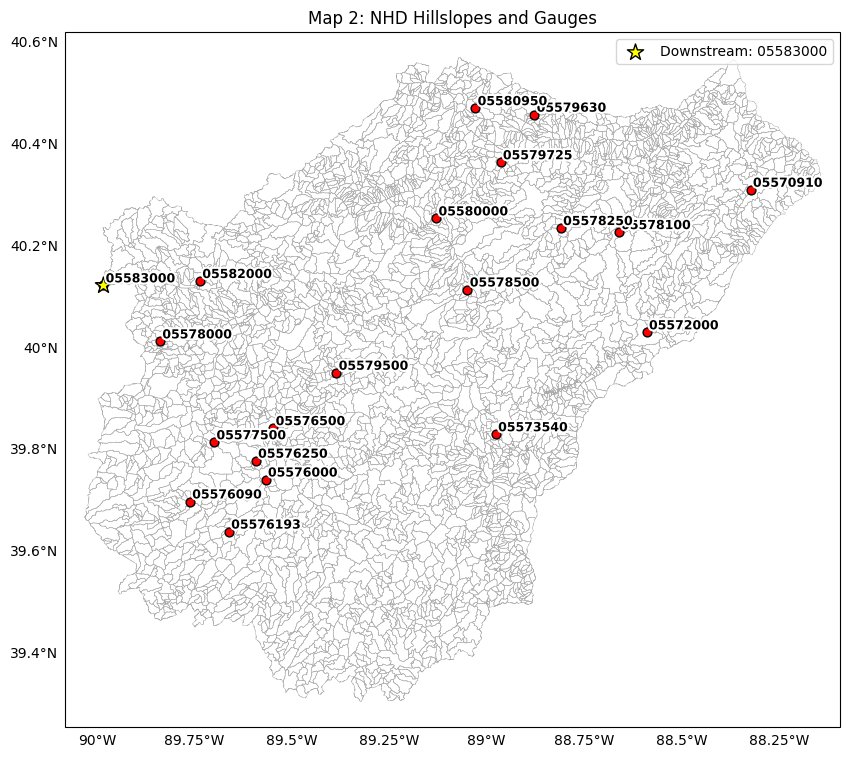

In [29]:
print("\n--- Generating Map 2: Hillslopes and Gauges ---")
# Check if necessary data is available
if overall_bounds and (catchment_nhd is not None and not catchment_nhd.empty):
    fig2, ax2 = create_basin_map(overall_bounds, title="Map 2: NHD Hillslopes and Gauges")

    # Plot NHD hillslopes
    catchment_nhd.plot(ax=ax2, facecolor="none", lw=0.3, edgecolor='darkgray', zorder=2)
    print("Plotted hillslopes.")

    # Plot NHD flowlines (optional, make them subtle if shown)
    # flowline_nhd.plot(ax=ax2, lw=0.3, color="lightblue", zorder=1, alpha=0.5)
    # print("Plotted subtle flowlines.")

    # Plot gauge points and labels
    plot_gauges(ax2, gauge_points, most_downstream_gauge_id)

    plt.show()
else:
    print("Skipping Map 2 due to missing boundary or NHD catchment data.")



## 6. Map 3: Individual USGS Gauge Catchments

This map displays the larger catchment areas associated with each selected USGS gauge, colored distinctly.


--- Generating Map 3: USGS Gauge Catchments ---
Plotted USGS catchments.
Plotted flowlines.
Attempted to plot 20 gauge points and labels.


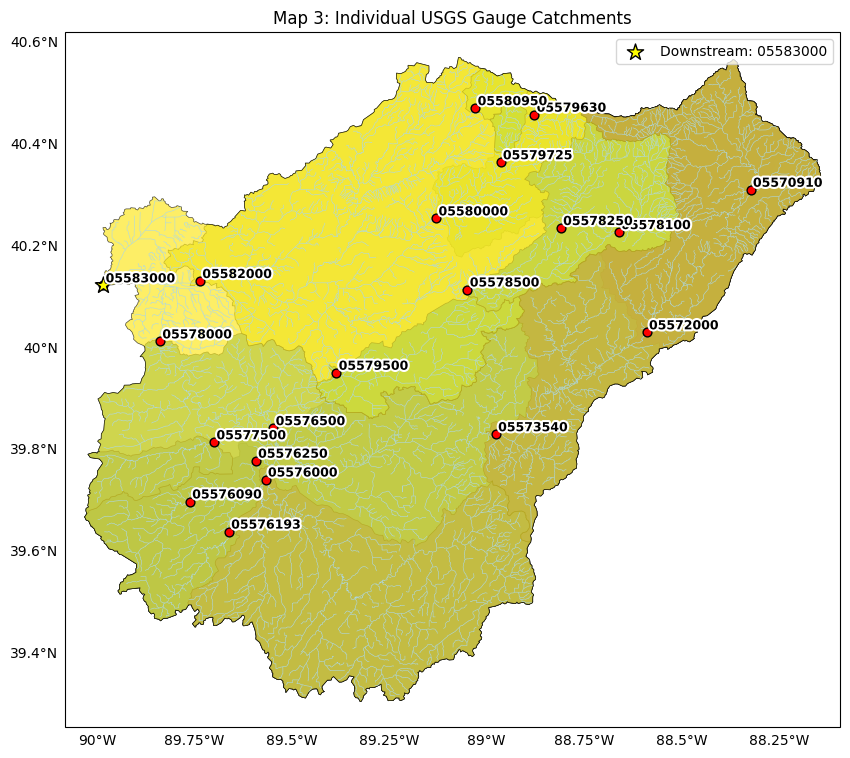

In [30]:
print("\n--- Generating Map 3: USGS Gauge Catchments ---")
# Check if necessary data is available
if overall_bounds and not usgs_catchments.empty and \
   (flowline_nhd is not None and not flowline_nhd.empty): # Keep flowlines for context
    fig3, ax3 = create_basin_map(overall_bounds, title="Map 3: Individual USGS Gauge Catchments")

    # Plot USGS gauge catchments
    if 'usgs_id' in usgs_catchments.columns:
        usgs_catchments.plot(ax=ax3, column='usgs_id', cmap='viridis', # Or tab20 if many gauges
                             legend=True, legend_kwds={'title': "USGS Gauge ID", 'loc': 'upper left', 'fontsize': 'small'},
                             edgecolor='black', linewidth=0.5, alpha=0.7, zorder=2) # Added some transparency back
        print("Plotted USGS catchments.")
    else:
        print("Warning: 'usgs_id' column not found in usgs_catchments, cannot plot polygons correctly.")

    # Plot NHD flowlines
    flowline_nhd.plot(ax=ax3, lw=0.4, color="lightblue", zorder=3) # Keep flowlines lighter
    print("Plotted flowlines.")

    # Plot gauge points and labels
    plot_gauges(ax3, gauge_points, most_downstream_gauge_id)

    plt.show()
else:
    print("Skipping Map 3 due to missing boundary, USGS catchment, or NHD flowline data.")




## 7. Map 4: Watershed Segmentation by Link Order (Placeholder)

This section requires data/logic for link order segmentation.



In [31]:
print("\n--- Generating Map 4: Link Order Segmentation (Placeholder) ---")
# (Placeholder logic remains the same)
link_order_data_loaded = False
if link_order_data_loaded:
    print("Placeholder executed. Add data loading and plotting logic for Map 4.")
else:
    print("Skipping Map 4: Data/logic for link order segmentation not implemented.")



--- Generating Map 4: Link Order Segmentation (Placeholder) ---
Skipping Map 4: Data/logic for link order segmentation not implemented.


## Analysis of Catchment, Hillslope, and Gauge Representations

Here is an explanation addressing the relationships between catchments, hillslopes, flowlines, and gauges as represented in the notebook's context:

1.  **Catchment Composition and Hillslope Delineation:**
    * A **catchment** (or watershed) is defined as the total land area contributing surface water flow to a single designated outlet point (e.g., a gauge location). This area inherently encompasses all the land surface units and stream channels upstream of that point.
    * **Hillslope delineation** is a process, often performed using Digital Elevation Models (DEMs) and stream network data (like NHDPlus), that subdivides the landscape into smaller drainage units. Each resulting polygon, often termed a "catchment" in NHDPlus High Resolution data (as loaded into `catchment_nhd` from `Catchment-*.gpkg`), typically represents the local land area draining *directly* to a specific segment of the stream network (`Flowline`).
    * Therefore, a larger catchment associated with a gauge is fundamentally **composed of** numerous smaller hillslope/catchment polygons. The hillslope delineation is not an automatic attribute *of* the gauge catchment definition itself but rather represents the granular, processed subdivision *within* it.
    * Regarding the link-hillslope relationship: In datasets like NHDPlus High Resolution, there is generally a **one-to-one correspondence** established during processing between a fundamental flowline segment (link, often identified by `NHDPlusID` or `FEATUREID`) and its associated local drainage area polygon (the "hillslope" or small "catchment" polygon loaded into `catchment_nhd`).

2.  **Catchments Plotted in Map 2:**
    * Map 2 visualizes the data stored in the `usgs_catchments` GeoDataFrame. This GeoDataFrame is created by filtering the `usgs-basins.geojson` file based on the list of IDs provided in `sangamon_gauge_ids`.
    * The output indicates that 16 unique gauge IDs from your list were successfully matched and found within the `usgs-basins.geojson` file.
    * Each polygon loaded from `usgs-basins.geojson` represents the **total upstream drainage area (catchment)** corresponding to a specific USGS gauge ID.
    * Therefore, Map 2 currently displays the **entire delineated upstream catchment** for each of the **16 USGS gauges** that were successfully identified and loaded from the `usgs-basins.geojson` source file.

3.  **Hillslope Link ID Association in Current Maps:**
    * The hillslopes are plotted in Map 1 using the geometries from the `catchment_nhd` GeoDataFrame.
    * Geospatial datasets like NHDPlus High Resolution (`Catchment-*.gpkg`) typically include **attribute columns** within the data that explicitly link each hillslope polygon to its corresponding flowline segment (link) ID (e.g., a column named `FEATUREID` or `NHDPlusID`).
    * While this linking attribute almost certainly exists within the *data* loaded into the `catchment_nhd` GeoDataFrame, the **current plotting code** for Map 1 (`catchment_nhd.plot(...)`) only utilizes the *geometry* of the hillslopes for visualization. It does **not** access or use the attribute column containing the link ID.
    * Consequently, the map, as currently generated by the code, does **not inherently display or utilize the specific link ID associated with each individual hillslope polygon.** To achieve this, the code would need to be modified to read and potentially use (e.g., for labeling or specific coloring) that linking attribute from the `catchment_nhd` GeoDataFrame.